In [1]:
import yaml
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import torch

In [2]:
with open("configs/config_signal.yaml") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)
signal = config["signal"]

filename2 = config[signal]["pt_hist_file_signal"]
print(filename2)
weights_file2 = uproot.open(filename2)
bin_counts, bin_edges = weights_file2["pt"].to_numpy()

/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger/pTs/Wwidemass.root


In [3]:
files = {
    # "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_new_pt_weights_2025-03-07/graphs_Wwidemass_1-2_ln_kT_cut_None_with_pt": {
    "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07/graphs_Wwidemass_1-2_ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07": {
        "label": "W wide mass",
        "ROOT_file": '/eos/home-t/tmlinare/Lund/jetetmiss/JETMDataMC/jpierre/run/submitDir-2025-01-06-1052-fee0 files 1-50/data-ANALYSIS/mc20_13TeV.802017.Py8EG_A14NNPDF23LO_WprimeWZ_flatpT_wideWmass.deriv.DAOD_JETM2.e8482_s3797_r13145_p5548.root'
    },
    # "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_new_pt_weights_2025-03-07/graphs_Wrealmass_3-4_ln_kT_cut_None_with_pt": {
    "/eos/home-t/tmlinare/Lund/Lund_tagging/lundtoptagger_data/graphs/ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07/graphs_Wrealmass_1-2_ln_kT_cut_None_with_pt_200_with_dsids_mcweights_new_pt_weights_2025-03-07": {
        "label": " real mass"
    }
}

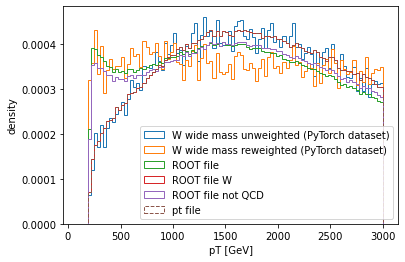

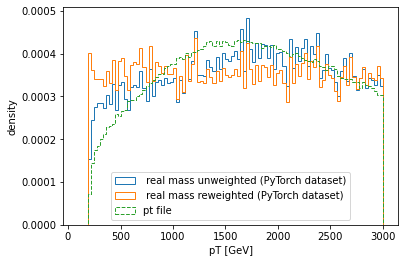

In [ ]:
hist_params = dict(bins=100, range=(100, 3000), histtype="step", density=True)
for file in files:
    dataset = torch.load(file)
    pts = np.array([jet.pt for jet in dataset])
    weights = np.array([jet.weights for jet in dataset])
    ys = np.array([jet.y for jet in dataset])
    plt.hist(pts[ys==1], **hist_params, label=files[file]["label"]+" unweighted (PyTorch dataset)")
    plt.hist(pts[ys==1], weights=weights[ys==1], **hist_params, label=files[file]["label"]+" reweighted (PyTorch dataset)")

    if "ROOT_file" in files[file]:

        ROOT_file = files[file]["ROOT_file"]

        with uproot.open(ROOT_file) as infile:
            tree = infile["AnalysisTree"]
            jet_pts = ak.flatten(tree["LRJ_pt"].array(library="ak"))
            truth_labels = ak.flatten(tree["LRJ_truthLabel"].array(library="ak"))

            pt_cut = 200
            plt.hist(jet_pts[jet_pts>pt_cut], label="ROOT file", **hist_params)
            plt.hist(jet_pts[(truth_labels==2) & (jet_pts>pt_cut)], label="ROOT file W", **hist_params)
            plt.hist(jet_pts[(truth_labels!=10) & (jet_pts>pt_cut)], label="ROOT file not QCD", **hist_params)

    plt.hist(bin_edges[:-1], bins=bin_edges, weights=bin_counts, density=True, histtype="step", label="pt file", linestyle="--")

    plt.xlabel("pT [GeV]")
    plt.ylabel("density")
    plt.legend()
    plt.show()

In [5]:
with open("configs/config_signal.yaml") as f:
    config = yaml.load(f, Loader=yaml.FullLoader)
signal = config["signal"]

# function from utils_newdata, modified to return some additional values
def GetPtWeight_2(truth_labels, pts, SF):

    ## PT histograms of all qcd and top jets in dataset
    filename1 = config[signal]["pt_hist_file_bkg"]
    filename2 = config[signal]["pt_hist_file_signal"]
    weights_file1 = uproot.open(filename1)
    flatweights_bg = weights_file1["pt"].to_numpy()
    weights_file2 = uproot.open(filename2)
    flatweights_sig = weights_file2["pt"].to_numpy()
    
    lenght_sig = len(flatweights_sig[0])
    lenght_bkg = len(flatweights_bg[0])
    #print("lenght_sig:", lenght_sig, "  lenght_bkg:", lenght_bkg)
    
    sig_bkg_proportion = 5  ## if is taked 5% of signal and 1% of qcd for training then sig_bkg_proportion=5
    scale_factor = (lenght_bkg/lenght_sig) / sig_bkg_proportion #1
    #print("scale_factor", scale_factor)
    
    weight_out = []
    Inv_hist_bg = []#flatweights_bg[0]
    Inv_hist_sig = []#flatweights_sig[0]
    
    ## it's time to calcuate the 1/hist
    for i in range (0,lenght_bkg):
        if flatweights_bg[0][i]==0:
            Inv_hist_bg.append(0)
            continue
        else:
            Inv_hist_bg.append(np.sum(flatweights_bg[0]) / (lenght_bkg * flatweights_bg[0][i]))
            
    for i in range (0,lenght_sig):
        if flatweights_sig[0][i]==0:
            Inv_hist_sig.append(0)
            continue
        else:
            Inv_hist_sig.append(np.sum(flatweights_sig[0]) / (lenght_sig * flatweights_sig[0][i]))

    for i in range(len(truth_labels)):
        pt_bin = int( ((pts[i]-100)/3000)*lenght_sig )
        if pt_bin>=lenght_sig : # ==
            pt_bin = lenght_sig-1
        if truth_labels[i]==10: # background could also be identified by DSIS, which would be < 370000
            #print("pt[i] ->", pt[i])
            #print("bin_pt->", pt_bin)
            weight_out.append( (Inv_hist_bg[pt_bin])*1  )
        if truth_labels[i]!=10: # this could also contain some non-signal jets which must be removed when creating the training dataset
            weight_out.append( (Inv_hist_sig[pt_bin]*scale_factor)*1 ) #*10**2 )
    return np.array(weight_out), Inv_hist_bg, Inv_hist_sig

In [6]:
# TODO: currently just using the values from the last file in the file dict; either do it for all files or explicitly set which one to use
flat_weights, Inv_hist_bg, Inv_hist_sig = GetPtWeight_2(truth_labels, jet_pts, 5)

In [7]:
flat_weights

array([0.16500668, 0.1646052 , 0.16238024, ..., 0.22722326, 0.15961778,
       0.16186903])

Text(0.5, 0, 'pT bin')

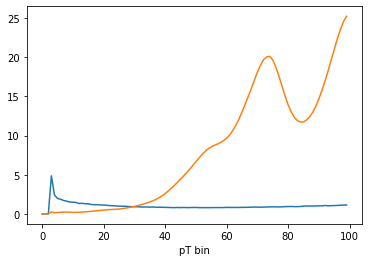

In [8]:
plt.plot(Inv_hist_sig, label="signal")
plt.plot(Inv_hist_bg, label="background")
plt.xlabel("pT bin")

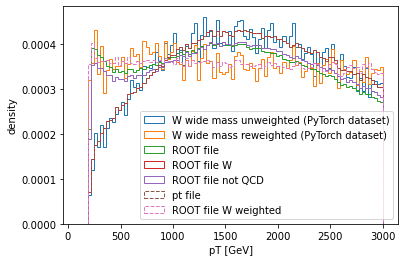

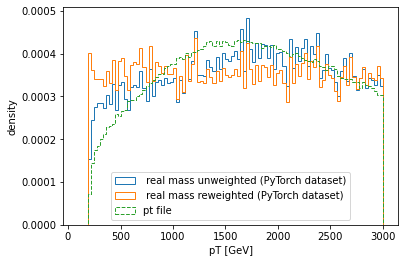

In [ ]:
# plot again, now also with reweighted data from the ROOT file
hist_params = dict(bins=100, range=(100, 3000), histtype="step", density=True)
for file in files:
    dataset = torch.load(file)
    pts = np.array([jet.pt for jet in dataset])
    weights = np.array([jet.weights for jet in dataset])
    ys = np.array([jet.y for jet in dataset])
    plt.hist(pts[ys==1], **hist_params, label=files[file]["label"]+" unweighted (PyTorch dataset)")
    plt.hist(pts[ys==1], weights=weights[ys==1], **hist_params, label=files[file]["label"]+" reweighted (PyTorch dataset)")

    if "ROOT_file" in files[file]:

        ROOT_file = files[file]["ROOT_file"]

        with uproot.open(ROOT_file) as infile:
            tree = infile["AnalysisTree"]
            jet_pts = ak.flatten(tree["LRJ_pt"].array(library="ak"))
            truth_labels = ak.flatten(tree["LRJ_truthLabel"].array(library="ak"))

            pt_cut = 200
            plt.hist(jet_pts[jet_pts>pt_cut], label="ROOT file", **hist_params)
            plt.hist(jet_pts[(truth_labels==2) & (jet_pts>pt_cut)], label="ROOT file W", **hist_params)
            plt.hist(jet_pts[(truth_labels!=10) & (jet_pts>pt_cut)], label="ROOT file not QCD", **hist_params)

    plt.hist(bin_edges[:-1], bins=bin_edges, weights=bin_counts, density=True, histtype="step", label="pt file", linestyle="--")

    if files[file]["label"] == "W wide mass":
        pt_weights = flat_weights[(truth_labels==2) & (jet_pts>pt_cut)]
        plt.hist(jet_pts[(truth_labels==2) & (jet_pts>pt_cut)], weights=pt_weights, **hist_params, label="ROOT file W weighted", linestyle="--")

    plt.xlabel("pT [GeV]")
    plt.ylabel("density")
    plt.legend()
    plt.show()